In [ ]:
%%writefile vector_add.cu
#include <iostream>
#include <vector>
#include <chrono>
using namespace std;

// CUDA Kernel for Vector Addition
__global__ void vectorAddGPU(const float *A, const float *B, float *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

// CPU Logic for Vector Addition
void vectorAddCPU(const float *A, const float *B, float *C, int N) {
    for (int i = 0; i < N; i++) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    // Array sizes to test
    int sizes[] = {10000, 50000, 100000, 500000, 1000000, 5000000, 10000000};
    int num_sizes = 7;

    cout << "Size,CPU_Time_ms,GPU_Time_ms\n";

    for (int s = 0; s < num_sizes; s++) {
        int N = sizes[s];
        size_t bytes = N * sizeof(float);

        vector<float> h_A(N, 1.0f);
        vector<float> h_B(N, 2.0f);
        vector<float> h_C_CPU(N, 0.0f);
        vector<float> h_C_GPU(N, 0.0f);

        // --- CPU Execution ---
        auto start_cpu = chrono::high_resolution_clock::now();
        vectorAddCPU(h_A.data(), h_B.data(), h_C_CPU.data(), N);
        auto end_cpu = chrono::high_resolution_clock::now();
        chrono::duration<float, milli> duration_cpu = end_cpu - start_cpu;

        // --- GPU Execution ---
        float *d_A, *d_B, *d_C;
        cudaMalloc(&d_A, bytes);
        cudaMalloc(&d_B, bytes);
        cudaMalloc(&d_C, bytes);

        // Include memory transfer in GPU time to accurately reflect Amdahl's serial bottleneck
        auto start_gpu = chrono::high_resolution_clock::now();

        cudaMemcpy(d_A, h_A.data(), bytes, cudaMemcpyHostToDevice);
        cudaMemcpy(d_B, h_B.data(), bytes, cudaMemcpyHostToDevice);

        int threadsPerBlock = 256;
        int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

        vectorAddGPU<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);
        cudaDeviceSynchronize();

        cudaMemcpy(h_C_GPU.data(), d_C, bytes, cudaMemcpyDeviceToHost);

        auto end_gpu = chrono::high_resolution_clock::now();
        chrono::duration<float, milli> duration_gpu = end_gpu - start_gpu;

        cout << N << "," << duration_cpu.count() << "," << duration_gpu.count() << "\n";

        cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    }
    return 0;
}

Overwriting vector_add.cu


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


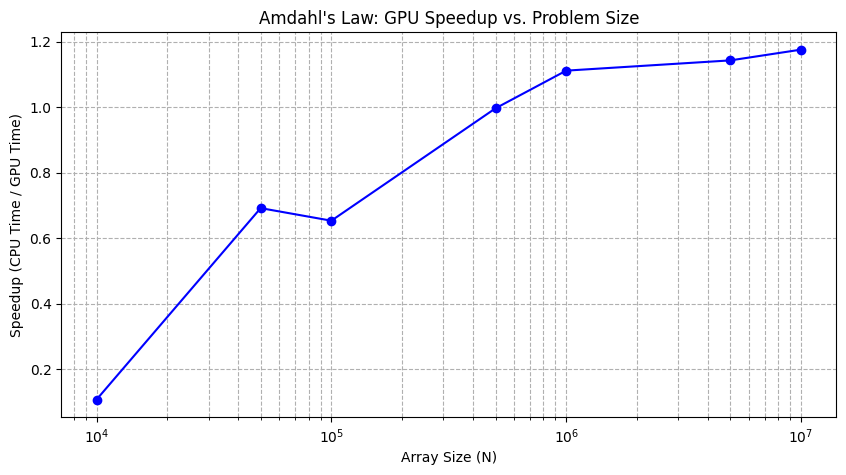

,Size,CPU_Time_ms,GPU_Time_ms,Speedup
0,10000,0.037197,0.348384,0.106770
1,50000,0.144870,0.209409,0.691804
2,100000,0.291901,0.446771,0.653357
3,500000,1.501640,1.506570,0.996728
4,1000000,3.028700,2.724080,1.111825
5,5000000,15.423400,13.492200,1.143135
6,10000000,31.656800,26.918500,1.176024


In [ ]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Compile the CUDA code
!nvcc vector_add.cu -o vector_add

# Run the executable and capture the output
result = subprocess.run(['./vector_add'], stdout=subprocess.PIPE, text=True)
data = result.stdout

# Read data into Pandas DataFrame
df = pd.read_csv(StringIO(data))

# Calculate Speedup
df['Speedup'] = df['CPU_Time_ms'] / df['GPU_Time_ms']

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df['Size'], df['Speedup'], marker='o', linestyle='-', color='b')
plt.title("Amdahl's Law: GPU Speedup vs. Problem Size")
plt.xlabel("Array Size (N)")
plt.ylabel("Speedup (CPU Time / GPU Time)")
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.show()

display(df)

In [ ]:
%%writefile matrix_mul.cu
#include <iostream>
using namespace std;

// CUDA Kernel for Matrix Multiplication
__global__ void matrixMulGPU(const float *A, const float *B, float *C, int N) {
    // Calculate global row and column indices
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    // Boundary check
    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += A[row * N + k] * B[k * N + col];
        }
        C[row * N + col] = sum;
    }
}

int main() {
    int N = 1024; // 1024x1024 matrix
    size_t bytes = N * N * sizeof(float);

    // Allocate host memory
    float *h_A = new float[N * N];
    float *h_B = new float[N * N];
    float *h_C = new float[N * N];

    // Initialize matrices
    for (int i = 0; i < N * N; i++) {
        h_A[i] = 1.0f;
        h_B[i] = 2.0f;
    }

    // Allocate device memory
    float *d_A, *d_B, *d_C;
    cudaMalloc(&d_A, bytes);
    cudaMalloc(&d_B, bytes);
    cudaMalloc(&d_C, bytes);

    // Copy data to device
    cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice);

    // Define Block and Grid dimensions (2D)
    dim3 threadsPerBlock(16, 16);
    dim3 blocksPerGrid((N + threadsPerBlock.x - 1) / threadsPerBlock.x,
                       (N + threadsPerBlock.y - 1) / threadsPerBlock.y);

    // Create CUDA Events for Timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Record the start event right before kernel launch
    cudaEventRecord(start);

    // Launch Kernel
    matrixMulGPU<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

    // Record the stop event right after kernel launch
    cudaEventRecord(stop);

    // Wait for the stop event to complete (synchronize)
    cudaEventSynchronize(stop);

    // Calculate time taken
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost);

    // Output results and time
    cout << "Matrix Multiplication completed." << endl;
    cout << "Kernel Execution Time: " << milliseconds << " ms" << endl;
    cout << "Value of C[0][0] = " << h_C[0] << " (Expected: " << N * 2.0f << ")" << endl;

    // Free memory and destroy events
    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    delete[] h_A; delete[] h_B; delete[] h_C;

    return 0;
}

Overwriting matrix_mul.cu


In [ ]:
!nvcc matrix_mul.cu -o matrix_mul
!./matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Matrix Multiplication completed.
Kernel Execution Time: 9.38029 ms
Value of C[0][0] = 2048 (Expected: 2048)
